# Lung Scalability Test

In [ ]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Load the lung scalability benchmark outputs and plot runtime / memory as the number of aligned patches increases.

In [1]:
def set_scalability_style():
    sns.set_theme(style="white", context="paper")
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 12,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "figure.dpi": 300,
    })


def format_patch_count_k(x):
    x = int(x)
    if x >= 1000:
        return f"{x // 1000}k" if x % 1000 == 0 else f"{x / 1000:.1f}k"
    return str(x)


def load_scalability_csv(results_csv):
    df = pd.read_csv(results_csv)

    numeric_cols = [
        "n_patches", "n_train", "n_val", "repeat", "epochs", "batch_size",
        "train_seconds", "seconds_per_epoch", "train_patches_per_second",
        "peak_gpu_memory_mb", "max_cpu_rss_mb", "load_seconds",
        "n_aligned_total",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def drop_warmup_outliers(df, metric, group_cols, factor=3.0):
    df = df.copy()
    df["is_warmup_outlier"] = False

    for _, idx in df.groupby(group_cols).groups.items():
        values = df.loc[idx, metric]
        if len(values) < 3:
            continue

        median_value = values.median()
        if median_value > 0:
            df.loc[idx, "is_warmup_outlier"] = values > factor * median_value

    return df[~df["is_warmup_outlier"]].copy()


def plot_scalability_metric(
    results_csv,
    figures_dir,
    metric,
    ylabel,
    title,
    out_name,
    x_col="n_patches",
    fixed_n_patches=None,
    exclude_xticks=(2500,),
    drop_warmup=True,
):
    df = load_scalability_csv(results_csv)

    if fixed_n_patches is not None:
        df = df[df["n_patches"] == fixed_n_patches].copy()
    elif x_col == "batch_size":
        df = df[df["n_patches"] == df["n_patches"].max()].copy()

    group_cols = [x_col]
    if "batch_size" in df.columns and x_col != "batch_size":
        group_cols.append("batch_size")

    if drop_warmup:
        df = drop_warmup_outliers(df, metric=metric, group_cols=group_cols)

    summary = (
        df.groupby(x_col, as_index=False)
        .agg(
            median=(metric, "median"),
            q25=(metric, lambda x: x.quantile(0.25)),
            q75=(metric, lambda x: x.quantile(0.75)),
            n_repeats=(metric, "count"),
        )
        .sort_values(x_col)
    )

    set_scalability_style()

    color = "#f86700"
    dot_color = "#222222"

    fig, ax = plt.subplots(figsize=(4.2, 3.2))

    ax.scatter(
        df[x_col],
        df[metric],
        s=22,
        color=dot_color,
        alpha=0.35,
        linewidth=0,
        label="Repeat",
        zorder=2,
    )

    ax.plot(
        summary[x_col],
        summary["median"],
        color=color,
        marker="o",
        linewidth=2.5,
        markersize=6,
        label="Median",
        zorder=3,
    )

    ax.fill_between(
        summary[x_col].to_numpy(),
        summary["q25"].to_numpy(),
        summary["q75"].to_numpy(),
        color=color,
        alpha=0.18,
        linewidth=0,
        label="IQR",
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Batch size" if x_col == "batch_size" else "Number of aligned lung patches")
    ax.set_ylabel(ylabel)

    xticks = summary[x_col].astype(int).tolist()
    if x_col == "n_patches":
        xticks = [x for x in xticks if x not in set(exclude_xticks)]
        ax.set_xticks(xticks)
        ax.set_xticklabels([format_patch_count_k(x) for x in xticks])
    else:
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(x) for x in xticks])

    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.35)
    ax.grid(axis="x", visible=False)
    ax.margins(x=0.04)
    ax.legend(title=None, frameon=False)

    sns.despine()
    fig.tight_layout()

    os.makedirs(figures_dir, exist_ok=True)
    fig.savefig(f"{figures_dir}/{out_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{figures_dir}/{out_name}.svg", bbox_inches="tight")
    plt.show()

    return df, summary


def plot_scalability_runtime(results_csv, figures_dir):
    return plot_scalability_metric(
        results_csv,
        figures_dir,
        metric="seconds_per_epoch",
        ylabel="Seconds per epoch",
        title="Training Time",
        out_name="lung_scalability_runtime",
        x_col="n_patches",
    )


def plot_scalability_throughput(results_csv, figures_dir):
    return plot_scalability_metric(
        results_csv,
        figures_dir,
        metric="train_patches_per_second",
        ylabel="Training patches / second",
        title="Training Throughput",
        out_name="lung_scalability_throughput",
        x_col="n_patches",
    )


def plot_batch_size_throughput(results_csv, figures_dir):
    return plot_scalability_metric(
        results_csv,
        figures_dir,
        metric="train_patches_per_second",
        ylabel="Training patches / second",
        title="Batch Size Scaling",
        out_name="lung_batch_size_scalability_throughput",
        x_col="batch_size",
    )


def plot_batch_size_runtime(results_csv, figures_dir):
    return plot_scalability_metric(
        results_csv,
        figures_dir,
        metric="seconds_per_epoch",
        ylabel="Seconds per epoch",
        title="Batch Size Runtime",
        out_name="lung_batch_size_scalability_runtime",
        x_col="batch_size",
    )

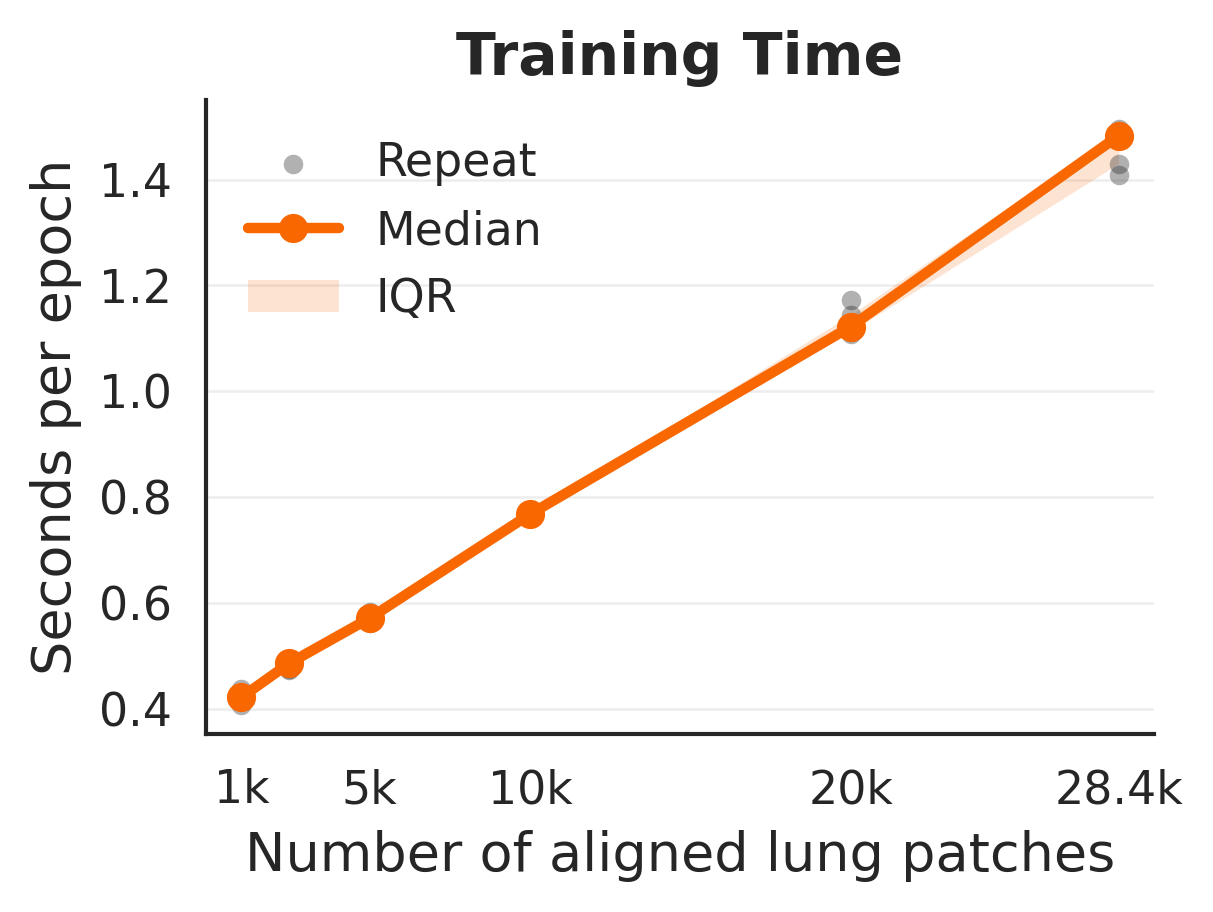

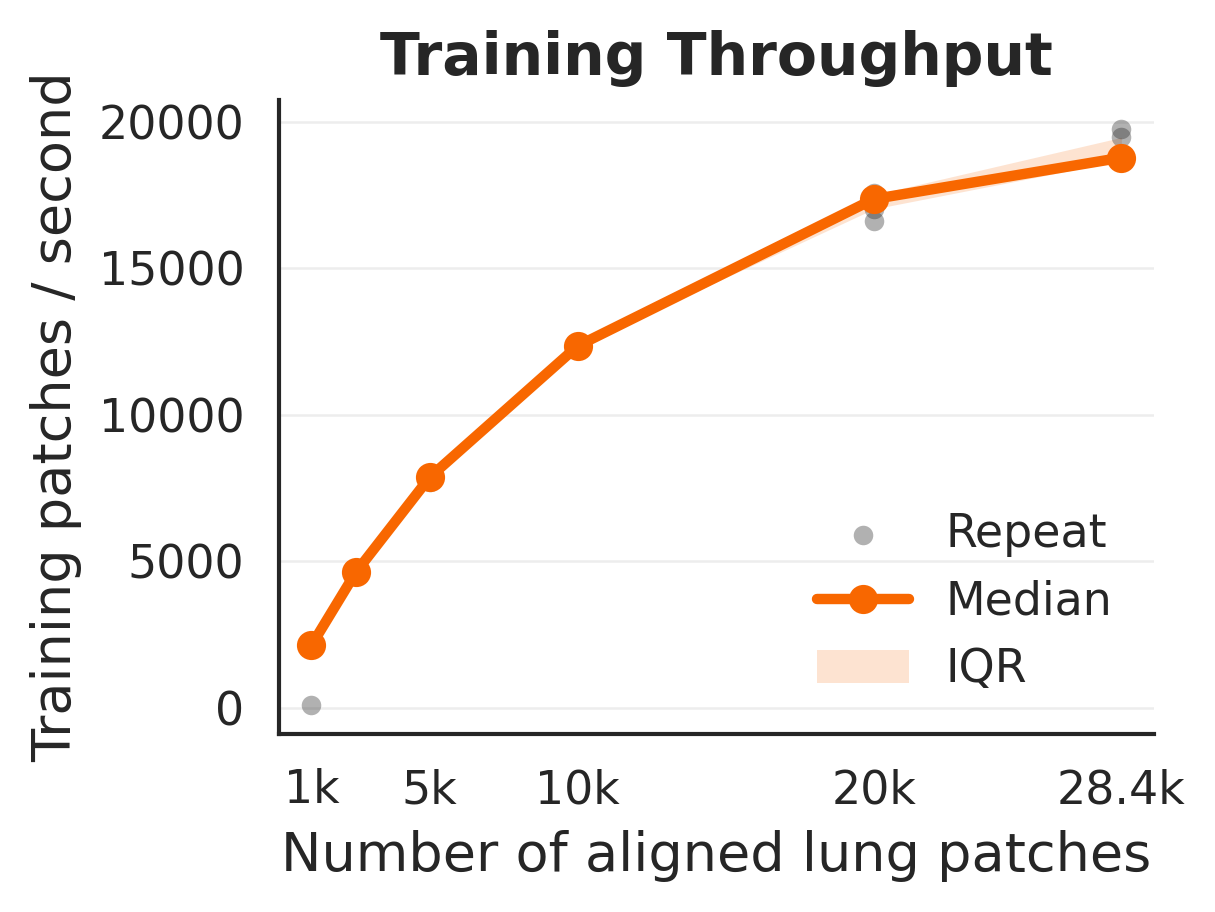

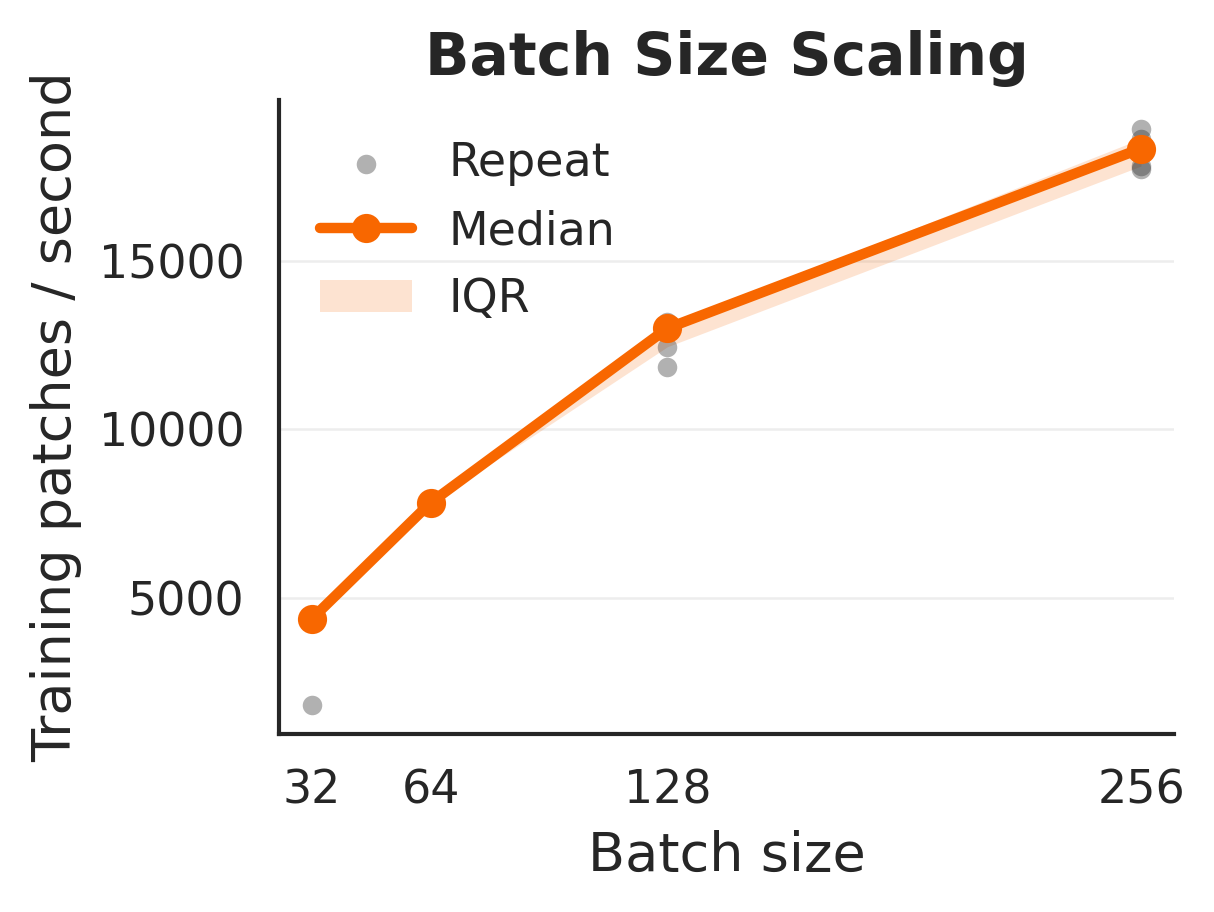

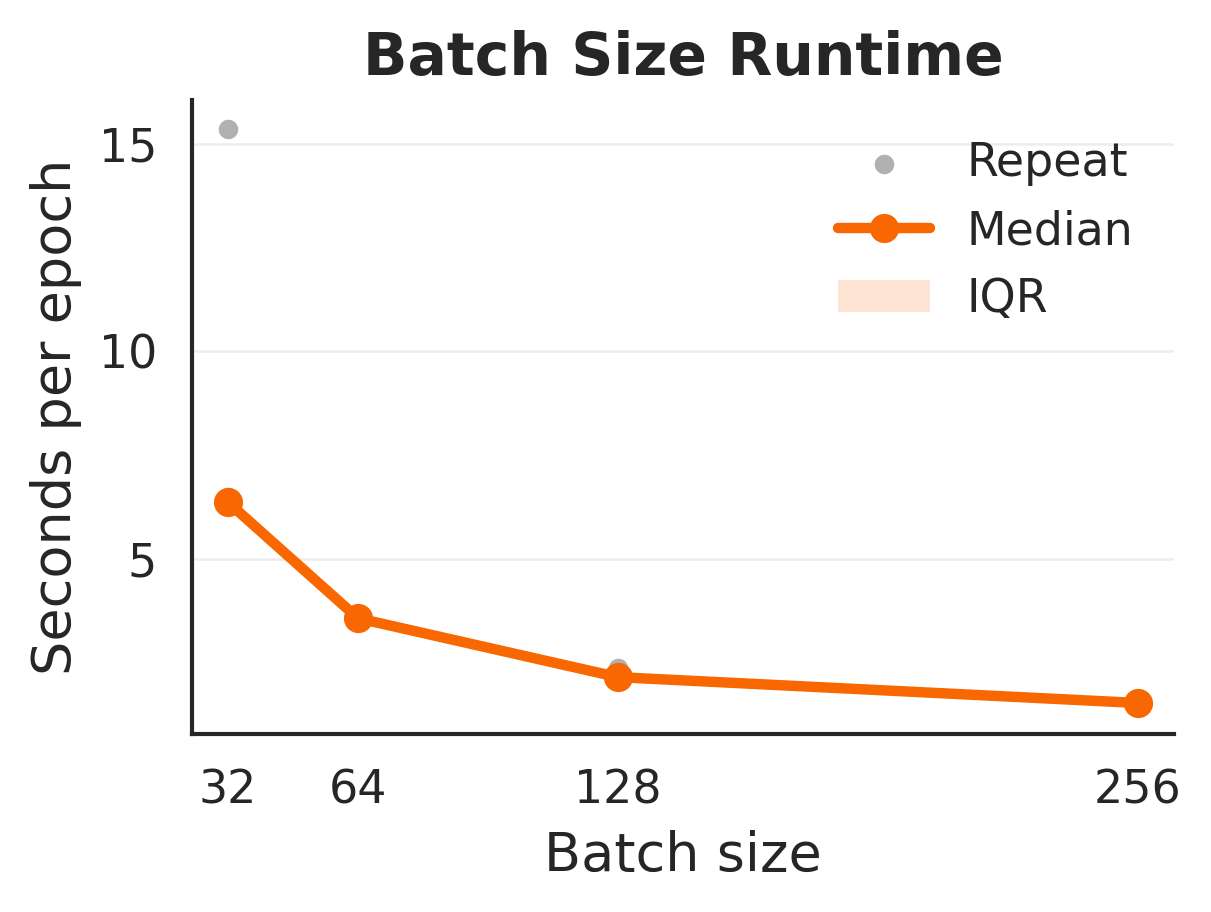

In [2]:
figures_dir = "/well/rittscher/users/mju725/trimodal_alignment_objects/figures"

size_csv = "/well/rittscher/users/mju725/trimodal_alignment_objects/lung/scalability_benchmark/lung_scalability_results.csv"
batch_csv = "/well/rittscher/users/mju725/trimodal_alignment_objects/lung/batch_size_scalability/lung_scalability_results.csv"

_, size_runtime = plot_scalability_runtime(size_csv, figures_dir)
_, size_throughput = plot_scalability_throughput(size_csv, figures_dir)

_, batch_throughput = plot_batch_size_throughput(batch_csv, figures_dir)
_, batch_runtime = plot_batch_size_runtime(batch_csv, figures_dir)